# Consumer preference modelling: Expressions for explanatory variables

$$
\newcommand{\dd}{\mathrm{d}}
%
\newcommand{\Icost}[1][n]{z_{{#1}1}}
\newcommand{\Csav}[1][n]{z_{{#1}2}}
\newcommand{\CoTwoSav}[1][n]{z_{{#1}3}}
\newcommand{\Fit}{z_{4}}
%
\newcommand{\Price}{\sigma}
%
\newcommand{\SuperNet}{\mathrm{net}}
\newcommand{\SuperGross}{\mathrm{gross}}
\newcommand{\SuperCHP}{\mathrm{(CHP)}}
\newcommand{\SuperStatusQuo}{\mathrm{(SQ)}}
\newcommand{\SuperImports}{\mathrm{imports}}
\newcommand{\SuperExports}{\mathrm{exports}}
\newcommand{\SuperDemand}{\mathrm{demand}}
%
\newcommand{\SubThermal}{\mathrm{th}}
\newcommand{\SubElectrical}{\mathrm{el}}
\newcommand{\SubBoiler}{\mathrm{B}}
\newcommand{\SubGenerator}{\mathrm{G}}
\newcommand{\SubNominal}{\mathrm{N}}
%
\newcommand{\time}{t}
\newcommand{\Pressure}{p}
\newcommand{\Temperature}{T}
\newcommand{\Volume}{V}
\newcommand{\TotalAmountOfSubstance}[2][]{n^{#1}_{#2}}
\newcommand{\MolarFlowRate}[2][]{F^{#1}_{#2}}
\newcommand{\MassFlowRate}[2][]{\dot{m}^{#1}_{#2}}
\newcommand{\ThermalPower}[2][]{\dot{Q}^{#1}_{#2}}
\newcommand{\ElectricalPower}[2][]{P^{#1}_{#2}}
\newcommand{\ReactionEnthalpy}[2][]{\Delta_\mathrm{r}H^{#1}_{#2}}
%
\newcommand{\SpecificCosts}[1]{c^\ast_{#1}}
\newcommand{\Efficiency}[2][]{\eta^{#1}_{#2}}
\newcommand{\AnnualHeatingDemand}[2][]{Q^{#1}_{#2}}
\newcommand{\AnnualElectricityDemand}[2][]{E^{#1}_{#2}}
%
\newcommand{\BoilerEfficiency}{\Efficiency{\SubBoiler}}
\newcommand{\GeneratorEfficiency}{\Efficiency{\SubGenerator}}
\newcommand{\ThermalEfficiency}[1][]{\Efficiency[#1]{\SubThermal}}
\newcommand{\ElectricalEfficiency}[1][]{\Efficiency[#1]{\SubElectrical}}
\newcommand{\PowerIndex}{\sigma}
$$

In [1]:
from datetime import datetime
import os
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display, Image, Latex
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from phdtools import DATA_DIR, RESULTS_DIR
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    request_free_id,
    auto_create_path,
    write_metadata,
)
from phdtools.models.rommel_sagebiel_2017 import MEAN_FLATSIZE

NUM_AGENTS = 512
MXL_COEFS_SMAPLE_SIZE = 512

TODAY = datetime.today().strftime("%y%m%d")
FILE_DATE = os.getenv("FILE_DATE", "260321")
FILE_DATE_AGENTS = os.getenv("FILE_DATE_AGENTS", "260321")
FILE_DATE_SAMPLE = os.getenv("FILE_DATE_SAMPLE", "260321")
FILE_DATE_REGRESSION = os.getenv("FILE_DATE_REGRESSION", "260321")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

## Table of contents

- [Investment costs](#Investment-costs)
- [Overall energy cost savings](#Overall-energy-cost-savings)
  - [Heating costs](#Heating-costs)
    - [Gas consumption for the status-quo option](#Gas-consumption-for-the-status-quo-option)
      - [Specific space and water heating demand](#Specific-space-and-water-heating-demand)
      - [Age structure of buildings in Germany](#Age-structure-of-buildings-in-Germany)
      - [Annual heat demand](#Annual-heat-demand)
    - [Gas consumption for the co-generation option](#Gas-consumption-for-the-co-generation-option)
    - [Heating cost savings](#Heating-cost-savings)
  - [Electricity costs](#Electricity-costs)
      - [Electricity costs for the status-quo option](#Electricity-costs-for-the-status-quo-option)
      - [Electricity costs for the co-generation option](#Electricity-costs-for-the-co-generation-option)
        - [Variant 1: Export fraction](#Variant-1:-Export-fraction)
        - [Variant 2: Degree of self-sufficiency](#Variant-2:-Degree-of-self-sufficiency)
      - [Electricity cost savings](#Electricity-cost-savings)
  - [Energy cost savings compared to status quo](#Energy-cost-savings-compared-to-status-quo)
- [CO2 savings](#CO2-savings)
  - [CO2 emissions for the status-quo option](#CO2-emissions-for-the-status-quo-option)
  - [CO2 emissions for the co-generation option](#CO2-emissions-for-the-co-generation-option)
  - [CO2 savings compared to status quo](#CO2-savings-compared-to-status-quo)
- [Product demand contours](#Product-demand-contour)
- [References](#References)

## Investment costs
[back](#Table-of-contents)

It is assumed that investment costs $\Icost$ are proportional to price $\Price{}$, taking a factor of $1.3$ to account for additional cost for planning and installation, neglecting variation between individual decision-makers $n$.

$$
\Icost[n] = 1.3 \Price{}
$$

In [2]:
from phdtools.optimization.preprocessing import icostEuroModel

icostEuroModel(10000)

13000.0

## Overall energy cost savings
[back](#Table-of-contents)

### Heating costs
[back](#Table-of-contents)

In [3]:
from phdtools.optimization import (
    NOMINAL_THERMAL_POWER_SI,
    GAS_PRICE_EUR_PER_KWH,
    NET_CALORIFIC_VALUE_METHANE_SI,
    GROSS_CALORIFIC_VALUE_METHANE_SI,
    REF_BOILER_EFFICIENCY,
    # MOLAR_FLOW_RATE_METHANE_IN_SI_LB,
    THERMAL_EFFICIENCY_STATUS_QUO,
)

Heating costs are billed based on gross calorific value (higher heating value, HHV) and fuel consumption. 
The operator usually applies a price $\SpecificCosts{\mathrm{gas}}$ given in $\mathrm{EUR} / \mathrm{kWh}$, and calculates the cost as 
\begin{align*}
  \text{heating costs} \ \text{in} \ \mathrm{EUR}
    = \SpecificCosts{\mathrm{gas}} \ \text{in} \ \mathrm{EUR} / \mathrm{kWh} \times
      \mathrm{HHV} \ \text{in} \ \mathrm{kWh / m^3} \times
      k_{\Volume{}} \times 
      \Volume{} \ \text{in} \ \mathrm{m^3}
\end{align*}

where a correction factor $k_{\Volume{}}$ is used to specify the consumption $\Volume{}$ in a standardized state.
This is expressed equivalently in molar quantities as the product of gas price $\SpecificCosts{\mathrm{gas}}$, molar heat of combustion $\ReactionEnthalpy{}(\Pressure{},\Temperature{})$ at operating pressure $\Pressure{}$ and temperature $\Temperature{}$, and amount of fuel consumed $\TotalAmountOfSubstance{\mathrm{gas}}$, that is 
\begin{align*}
  \text{heating costs}
    = \SpecificCosts{\mathrm{gas}} \,
      \ReactionEnthalpy[\SuperGross]{} \,
      \TotalAmountOfSubstance{\mathrm{gas}}
\end{align*}

#### Gas consumption for the status-quo option
[back](#Table-of-contents)

For an installation $n$
$$
\begin{aligned}
  \TotalAmountOfSubstance[\SuperStatusQuo]{\mathrm{gas},n} 
    &= \int_0^{\tau} \MolarFlowRate[\SuperStatusQuo]{\ce{CH4},n} \dd \time 
\end{aligned}
$$

With the definition of boiler efficiency $\BoilerEfficiency \coloneqq \ThermalPower{} / (\MassFlowRate{\mathrm{fuel}} \mathrm{LHV}) = 0.9 \approx const.$ (see [European Commission, 2015, Annex II](#References))

$$
\begin{aligned}
  \TotalAmountOfSubstance[\SuperStatusQuo]{\mathrm{gas}} 
    % &= \int_0^{\tau} \MolarFlowRate[\SuperStatusQuo]{\ce{CH4},n} \dd \time \\
    = \int_0^{\tau} \frac{\ThermalPower{n}}{\BoilerEfficiency{}\ReactionEnthalpy[\SuperNet]{}} \dd \time 
    = \frac{\AnnualHeatingDemand{n}}{\BoilerEfficiency{}\ReactionEnthalpy[\SuperNet]{}}
    = \frac{\AnnualHeatingDemand{n}}{\ThermalEfficiency[\SuperStatusQuo]{}\ReactionEnthalpy[\SuperGross]{}}
\end{aligned}
$$

In [4]:
from phdtools.data import ISO_STD_REF_TEMPERATURE_SI
from phdtools.data.thermochemical import get_stdReactionEnthalpyFromKirchhoffsLaw
from phdtools.optimization import (
    NET_CALORIFIC_VALUE_METHANE_SI,
    GROSS_CALORIFIC_VALUE_METHANE_SI,
)

get_stdReactionEnthalpyFromKirchhoffsLaw(
    ISO_STD_REF_TEMPERATURE_SI, reactions={"MCR1", "MCR2"}
)

MCR2   -891243.40
MCR1   -802400.18
Name: 288.15, dtype: float64

In [5]:
display(
    Latex(
        rf"At $T = T_\mathrm{{ISO}} = {ISO_STD_REF_TEMPERATURE_SI} \, \mathrm{{K}}$:"
    ),
    Latex(
        rf"Net calorific value of methane: ${NET_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$"
    ),
    Latex(
        rf"Gross calorific value of methane: ${GROSS_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$"
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [6]:
display(
    Latex(rf"$\eta_\mathrm{{B}} = {REF_BOILER_EFFICIENCY:.4f}$"),
    Latex(rf"$\eta_\mathrm{{th}} = {THERMAL_EFFICIENCY_STATUS_QUO:.4f}$"),
    # Latex(rf"$\Delta_\mathrm{{r}}H^\mathrm{{net}} = {NET_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$"),
    # Latex(rf"$\Delta_\mathrm{{r}}H^\mathrm{{gross}} = {GROSS_CALORIFIC_VALUE_METHANE_SI/1000:.4f} \, \mathrm{{kJ/mol}}$")
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
THERMAL_EFFICIENCY_STATUS_QUO == NET_CALORIFIC_VALUE_METHANE_SI / GROSS_CALORIFIC_VALUE_METHANE_SI * REF_BOILER_EFFICIENCY

np.True_

##### Specific space and water heating demand 
[back](#Table-of-contents)

See [Kemmler (2015)](#References).

In [8]:
!ls {DATA_DIR / "uba-2016"}

260112_Tabelle_2_4.csv


In [9]:
fname = DATA_DIR / "uba-2016" / "260112_Tabelle_2_4.csv"
pd.read_csv(
    fname,
    skiprows=[0, 1],
    names=[
        "Detached house",
        "Semi-detached house",
        "Apartment building (3 - 6 dwellings)",
        "Apartment building (7 - 12 dwellings)",
        "Apartment building (13 - 20 dwellings)",
        "Apartment building (> 20 dwellings)",
        "Non-residential buildings with residential units",
    ],
)

,Detached house,Semi-detached house,Apartment building (3 - 6 dwellings),Apartment building (7 - 12 dwellings),Apartment building (13 - 20 dwellings),Apartment building (> 20 dwellings),Non-residential buildings with residential units
bis 1918,136,121,107,98,92,90,126
1919 - 1948,146,129,109,99,92,90,133
1949 - 1978,152,133,111,101,94,92,130
1979 - 1990,118,104,92,84,79,77,107
1991 - 2000,99,87,82,73,68,67,90
2000 - 2004,87,77,71,64,59,58,73
2005 - 2008,84,74,65,59,55,53,64
2009 - 2012,68,60,51,45,42,41,54


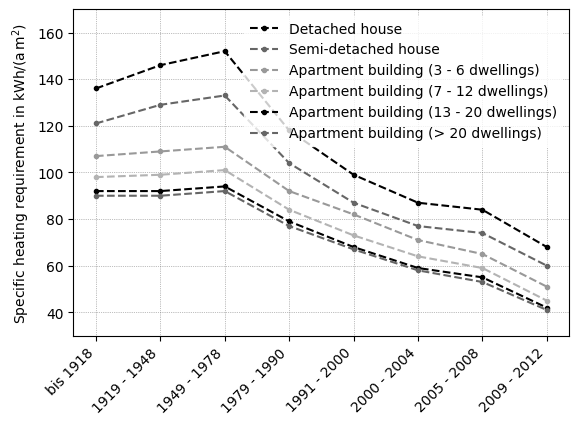

In [10]:
from phdtools.plots.optimization.preprocessing import (
    plot_specific_heating_demand_by_year_and_type,
)

_ = plot_specific_heating_demand_by_year_and_type(
    fname=DATA_DIR / "uba-2016" / "260112_Tabelle_2_4.csv"
)

##### Age structure of buildings in Germany
[back](#Table-of-contents)

See [StBA (2025)](#References).

In [11]:
!ls {DATA_DIR / "stba-2025"}

4000W-3009_en_flat.csv 4000W-3009_en.csv


In [12]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 7)

fname = DATA_DIR / "stba-2025" / "4000W-3009_en_flat.csv"

dwellings_col = "Dwellings in the building"
year_col = "Year of construction (microcensus categories)"
area_col = "Floor area of the dwelling (10m² increments)"
numbers_col = "Dwellings in buildings with residential space"

year_order = [
    "Before 1919",
    "1919 - 1948",
    "1949 - 1978",
    "1979 - 1990",
    "1991 - 2000",
    "2001 - 2010",
    "2011 - 2019",
    "2020 and later",
    "Total",
]

area_order = [
    "Under 30 m²",
    "30 - 39 m²",
    "40 - 49 m²",
    "50 - 59 m²",
    "60 - 69 m²",
    "70 - 79 m²",
    "80 - 89 m²",
    "90 - 99 m²",
    "100 - 109 m²",
    "110 - 119 m²",
    "120 - 129 m²",
    "130 - 139 m²",
    "140 - 149 m²",
    "150 - 159 m²",
    "160 - 169 m²",
    "170 - 179 m²",
    "180 m² and more",
    "Total",
]

dwellings_order = [
    "1 dwelling",
    "2 dwellings",
    "3 - 6 dwellings",
    "7 - 12 dwellings",
    "13 dwellings or more",
    "Total",
]

df = pd.read_csv(
    fname,
    delimiter=";",
    usecols=[12, 16, 20, 21],
    skiprows=1,
    names=[
        "Year of construction (microcensus categories)",
        "Floor area of the dwelling (10m² increments)",
        "Dwellings in the building",
        "Dwellings in buildings with residential space",
    ],
)

df[year_col] = pd.Categorical(df[year_col], categories=year_order, ordered=True)
df[area_col] = pd.Categorical(df[area_col], categories=area_order, ordered=True)
df[dwellings_col] = pd.Categorical(
    df[dwellings_col], categories=dwellings_order, ordered=True
)


@auto_create_path
def save_dwellings_floor_area_by_year(path):
    for dwellings in dwellings_order:
        description = "None"

        table = pd.pivot_table(
            df[df[dwellings_col] == dwellings],
            index=area_col,
            columns=year_col,
            values=numbers_col,
            aggfunc="sum",
            dropna=False,  # keep full grid (we reindex anyway)
            observed=False,
        ).reindex(index=area_order, columns=year_order)

        fname = (
            path
            / f"{TODAY}_floor_area_by_year_{dwellings.replace(" ", "_").replace("-", "to")}.csv"
        )
        with open(fname, "w") as f:
            write_metadata(f, description)
            table.to_csv(f, sep=",")


save_dwellings_floor_area_by_year(
    data_id,
    doc=r"Number of dwellings by floor area and year in Germany according to the 2022 census; see \textcite{StBA.2025c}",
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/4aOulh' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [13]:
!ls {data_id.get_path(fail_exists=False)}

260319_floor_area_by_year_1_dwelling.csv
260319_floor_area_by_year_13_dwellings_or_more.csv
260319_floor_area_by_year_2_dwellings.csv
260319_floor_area_by_year_3_to_6_dwellings.csv
260319_floor_area_by_year_7_to_12_dwellings.csv
260319_floor_area_by_year_Total.csv


In [14]:
from phdtools.plots.optimization.preprocessing import plot_floor_area_by_year_bar_chart

##### Single family homes

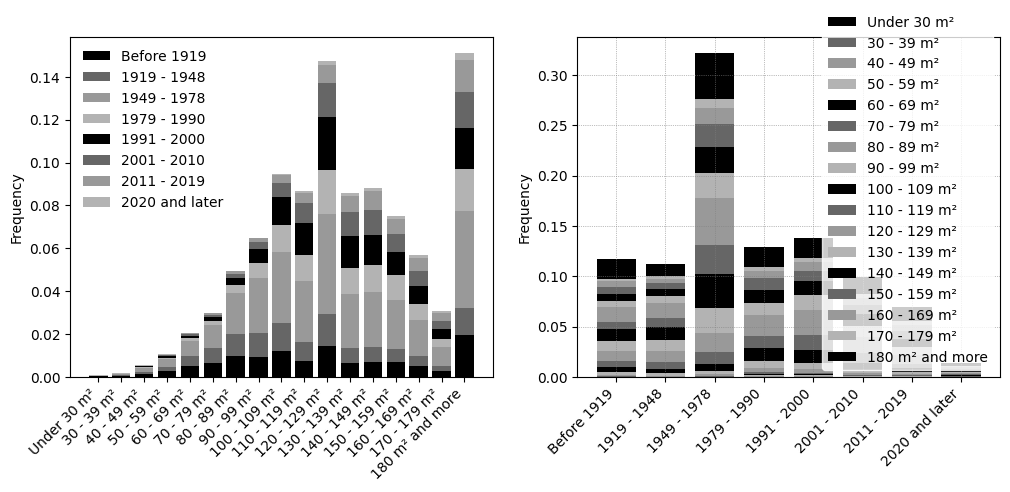

In [15]:
_ = plot_floor_area_by_year_bar_chart(
    fname=data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_floor_area_by_year_1_dwelling.csv"
)

In [16]:
table = pd.read_csv(
    data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_floor_area_by_year_1_dwelling.csv",
    index_col=0,
    comment="#",
)

table.loc["Total"] / table.loc["Total", "Total"]

Before 1919       0.116740
1919 - 1948       0.112612
1949 - 1978       0.321570
1979 - 1990       0.129246
1991 - 2000       0.137570
2001 - 2010       0.098719
2011 - 2019       0.069734
2020 and later    0.013808
Total             1.000000
Name: Total, dtype: float64

##### Two family homes

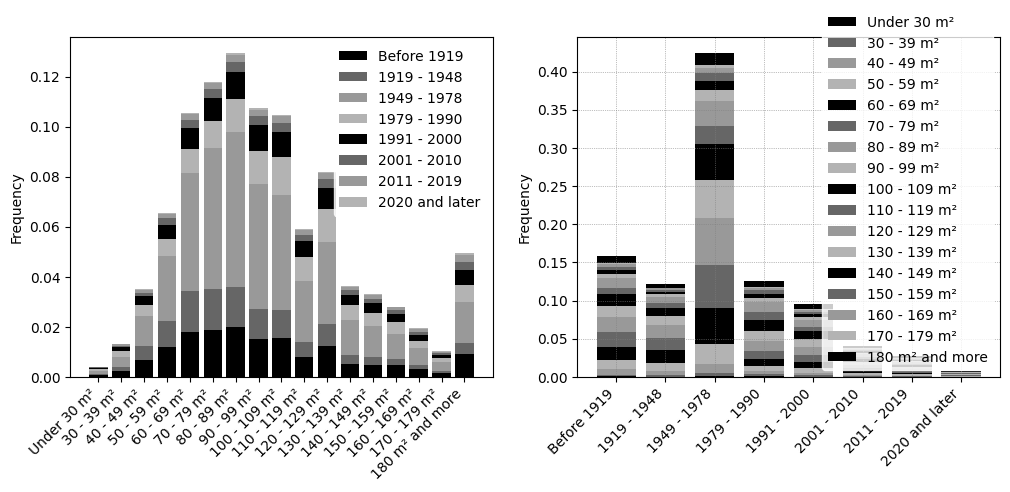

In [17]:
_ = plot_floor_area_by_year_bar_chart(
    fname=data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_floor_area_by_year_2_dwellings.csv"
)

In [18]:
table = pd.read_csv(
    data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_floor_area_by_year_2_dwellings.csv",
    index_col=0,
    comment="#",
)
table.loc["Total"] / table.loc["Total", "Total"]

Before 1919       0.158131
1919 - 1948       0.121343
1949 - 1978       0.424167
1979 - 1990       0.125150
1991 - 2000       0.095069
2001 - 2010       0.040855
2011 - 2019       0.027348
2020 and later    0.007936
Total             1.000000
Name: Total, dtype: float64

##### Annual heat demand
[back](#Table-of-contents)

In [19]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)}

260319_socio_demographic_attributes_1024.csv
260319_socio_demographic_attributes_128.csv
260319_socio_demographic_attributes_16.csv
260319_socio_demographic_attributes_2.csv
260319_socio_demographic_attributes_256.csv
260319_socio_demographic_attributes_32.csv
260319_socio_demographic_attributes_4.csv
260319_socio_demographic_attributes_512.csv
260319_socio_demographic_attributes_64.csv
260319_socio_demographic_attributes_8.csv


In [20]:
socio_demographic_attributes = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)

mask = socio_demographic_attributes["HEATSYS"] == 1
socio_demographic_attributes = socio_demographic_attributes[mask]
socio_demographic_attributes.describe()

,AGE,SEX,INCOME,ENECOST,FLATSIZE,HEATSYS
count,221.000000,221.000000,221.000000,221.000000,221.000000,221.0
mean,-0.614885,0.493213,6.559495,3.443647,1.748742,1.0
std,16.841035,0.501089,3.849341,1.273458,39.106909,0.0
min,-30.650000,0.000000,1.000000,1.000000,-79.990000,1.0
25%,-13.333511,0.000000,3.099435,2.454275,-25.855235,1.0
50%,-1.379735,0.000000,6.260359,3.572273,2.631367,1.0
75%,10.553028,1.000000,9.643671,4.397552,28.272839,1.0
max,40.299612,1.000000,13.000000,6.000000,114.302045,1.0


In [21]:
import csv


def _record_sample_sizes(infile, outfile):

    if not os.path.exists(outfile):
        with open(outfile, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["sample_size", "N(HEATSYS=1)"])

    df = pd.read_csv(infile, comment="#")
    mask = df["HEATSYS"] == 1

    with open(outfile, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([len(df), sum(mask)])

In [22]:
from phdtools.models.rommel_sagebiel_2017 import MEAN_FLATSIZE
from phdtools.optimization.preprocessing import (
    annualHeatDemandModel,
    SPECIFIC_SPACE_HEATING_DEMAND_SI_PER_YEAR,
    SPECIFIC_WATER_HEATING_DEMAND_SI_PER_YEAR,
)

data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 4)


@auto_create_path
def save_annual_head_demands(path, sample_sizes=[16, 32, 64, 128, 256, 512, 1024]):

    if os.path.exists(path / f"{FILE_DATE}_sample_sizes.csv") and overwrite:
        os.remove(path / f"{FILE_DATE}_sample_sizes.csv")

    for sample_size in sample_sizes:
        fname_s = (
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        _record_sample_sizes(
            infile=fname_s, outfile=path / f"{FILE_DATE}_sample_sizes.csv"
        )

        annualHeatDemandSI = annualHeatDemandModel(
            fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        description = (
            "Annual heating demand (in Joule per year) of agents n (conditional on HEATSYS = 1)\n"
            "calculated from the agents socio-demographic attribute FLATSIZE:\n"
            "\n  (SPECIFIC_SPACE_HEATING_DEMAND_SI_PER_YEAR + SPECIFIC_WATER_HEATING_DEMAND_SI_PER_YEAR) x \\\n"
            "    (FLATSIZE + MEAN_FLATSIZE)\n\n"
            f"with: MEAN_FLATSIZE = {MEAN_FLATSIZE}; \n"
            f"  SPECIFIC_SPACE_HEATING_DEMAND_SI = {SPECIFIC_SPACE_HEATING_DEMAND_SI_PER_YEAR/1000} kW h / (a m2) (Statistical Offices Of The Federation And The Länder, 2025)\n"
            f"  SPECIFIC_WATER_HEATING_DEMAND_SI = {SPECIFIC_WATER_HEATING_DEMAND_SI_PER_YEAR/1000} kW h / (a m2) (Gebäudeenergiegesetz, 2020).\n"
            "The socio-demographic attributes are given in\n\n"
            f'    "RESULTS_DIR/{fname_s.relative_to(RESULTS_DIR)}"\n\n'
            "\n"
            "References:\n"
            "-----------\n"
            "Gebäudeenergiegesetz (2020) BGBl. I 2020, S. 1728. Available at: \n"
            "  https://www.gesetze-im-internet.de/geg/.\n\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "  Germany: Policy implications for grid expansion from a discrete choice\n"
            "  experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "  https://doi.org/10.1016/j.apenergy.2017.08.216.\n\n"
            'Statistical Offices Of The Federation And The Länder (2025) "Dwellings: \n'
            "  Year of construction (microcensus categories)/Rooms - Floor area of the \n"
            '  dwelling (10m² increments) - Dwellings in the building." \n'
            "  https://ergebnisse.zensus2022.de: Zensus Datenbank. Available at: \n"
            "  https://ergebnisse.zensus2022.de/datenbank/online/url/48ed0498 \n"
            "  (Accessed: January 12, 2026).\n"
        )
        fname = path / f"{TODAY}_annual_heating_demands_{sample_size}.csv"
        with open(fname, "w") as f:
            write_metadata(f, description=description)
            annualHeatDemandSI.to_csv(f)


save_annual_head_demands(
    data_id,
    doc=r"Estimated annual heating demands calculated from the attribute value of floor area ($\mathrm{FLATSIZE}$); see \textcite{Rommel.2017a}",
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/dO45w5' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [23]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)}

260319_annual_heating_demands_1024.csv 260319_annual_heating_demands_32.csv
260319_annual_heating_demands_128.csv  260319_annual_heating_demands_512.csv
260319_annual_heating_demands_16.csv   260319_annual_heating_demands_64.csv
260319_annual_heating_demands_256.csv  260319_sample_sizes.csv


In [24]:
annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]

annualHeatDemandSI

AGENT
4      6.645460e+10
6      2.129003e+10
8      3.631812e+10
9      4.284541e+10
11     4.098282e+10
           ...     
500    3.037766e+10
502    4.277424e+10
506    5.515400e+10
508    3.755717e+10
511    5.564109e+10
Name: annualHeatDemandSI, Length: 221, dtype: float64

In [25]:
heatingCostStatusQuo = (
    (GAS_PRICE_EUR_PER_KWH * 1e-3 / 3600)
    * annualHeatDemandSI
    / THERMAL_EFFICIENCY_STATUS_QUO
).rename("heatingCostStatusQuo")
heatingCostStatusQuo.head()

AGENT
4     2733.799002
6      875.825996
8     1494.049405
9     1762.567825
11    1685.944830
Name: heatingCostStatusQuo, dtype: float64

#### Gas consumption for the co-generation option
[back](#Table-of-contents)

For an installation $n$
$$
\begin{aligned}
  \TotalAmountOfSubstance[\SuperCHP]{\mathrm{gas},n} 
    &= \int_0^{\tau} \MolarFlowRate[\SuperCHP]{\ce{CH4},n} \dd \time 
\end{aligned}
$$

With the definition of thermal efficiency $\ThermalEfficiency \coloneqq \ThermalPower{} / (\MassFlowRate{\mathrm{fuel}} \mathrm{HHV})$, 
assuming $\ThermalEfficiency = const.$

$$
% \ThermalEfficiency \, \ReactionEnthalpy[\SuperGross]{} = 
\frac{\ThermalPower{n}}{\MolarFlowRate[\SuperCHP]{\ce{CH4},n}} 
    = \frac{\ThermalPower{\SubNominal}}{\MolarFlowRate[\SuperCHP]{\ce{CH4},\SubNominal}} 
\implies 
    \MolarFlowRate[\SuperCHP]{\ce{CH4},n} 
    = \frac{\ThermalPower{n}}{\ThermalEfficiency \, \ReactionEnthalpy[\SuperGross]{}} 
    = \frac{\ThermalPower{n}}{\ThermalPower{\SubNominal}} \MolarFlowRate[\SuperCHP]{\ce{CH4},\SubNominal}
$$

$$
\begin{aligned}
  \TotalAmountOfSubstance[\SuperCHP]{\mathrm{gas}} 
    = \int_0^{\tau} \frac{\ThermalPower{n}}{\ThermalPower{\SubNominal}} \MolarFlowRate[\SuperCHP]{\ce{CH4},\SubNominal} \dd \time 
    = \frac{\AnnualHeatingDemand{n}}{\ThermalPower{\SubNominal}} \MolarFlowRate{\ce{CH4}}
    = \frac{\AnnualHeatingDemand{n}}{\ThermalEfficiency \, \ReactionEnthalpy[\SuperGross]{}} 
\end{aligned}
$$

In [26]:
thermalEfficiency = 0.9

annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]

# molarFlowRateMethaneSI = -NOMINAL_THERMAL_POWER_SI / (thermalEfficiency*GROSS_CALORIFIC_VALUE_METHANE_SI)
# heatingCostCHP = (-1 * (GAS_PRICE_EUR_PER_KWH * 1e-3) * GROSS_CALORIFIC_VALUE_METHANE_SI *
#     (annualHeatDemandSI / NOMINAL_THERMAL_POWER_SI  * molarFlowRateMethaneSI) ).rename("heatingCostCHP")

heatingCostCHP = (
    (GAS_PRICE_EUR_PER_KWH * 1e-3 / 3600) * annualHeatDemandSI / thermalEfficiency
).rename("heatingCostCHP")

heatingCostCHP.head()

AGENT
4     2461.281409
6      788.519654
8     1345.115724
9     1586.866999
11    1517.882136
Name: heatingCostCHP, dtype: float64

#### Heating cost savings
[back](#Table-of-contents)

In [27]:
from phdtools.optimization.preprocessing import heatingCostSavingsModel

$$
\text{heating cost savings} 
    = \SpecificCosts{\mathrm{gas}} \, \AnnualHeatingDemand{n} \, \left(
    \frac{\ReactionEnthalpy[\SuperGross]{}}{\BoilerEfficiency{}\ReactionEnthalpy[\SuperNet]{}} - \frac{\ReactionEnthalpy[\SuperGross]{}}{\ThermalPower{\SubNominal}} \MolarFlowRate{\ce{CH4}}
    \right) 
    = \SpecificCosts{\mathrm{gas}} \, \AnnualHeatingDemand{n} \, \left(
    \frac{1}{\ThermalEfficiency[\SuperStatusQuo]} - \frac{1}{\ThermalEfficiency[\SuperCHP]}
    \right)
$$

In [28]:
thermalEfficiency = 0.9

annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]

heatingCostSavings = heatingCostSavingsModel(thermalEfficiency, annualHeatDemandSI)

heatingCostSavings.head()

AGENT
4     272.517593
6      87.306343
8     148.933681
9     175.700825
11    168.062695
Name: annualHeatDemandSI, dtype: float64

In [29]:
all(np.isclose(heatingCostSavings - (heatingCostStatusQuo - heatingCostCHP), 0))

True

The heating cost savings in percent compared to satus-quo are independe of the demand and also the cost:
$$
\text{heating cost savings relative to satus-quo} = \frac{ \SpecificCosts{\mathrm{gas}} \, \AnnualHeatingDemand{n} \, \left(
    1/\ThermalEfficiency[\SuperStatusQuo] - 1/\ThermalEfficiency[\SuperCHP]
    \right)}{\SpecificCosts{\mathrm{gas}} \, \AnnualHeatingDemand{n} /\ThermalEfficiency[\SuperStatusQuo] } = \left(
    1 - \frac{\ThermalEfficiency[\SuperStatusQuo]}{\ThermalEfficiency[\SuperCHP]} \right)
$$

In [30]:
thermalEfficiency = 0.9

Latex(
    rf"With $\eta^{{(\mathrm{{SQ}})}}_\mathrm{{th}} = {thermalEfficiency}$, the heating cost savings "
    rf"compared to the status quo are ${100*(1-THERMAL_EFFICIENCY_STATUS_QUO/thermalEfficiency):.2f}\%$"
)

<IPython.core.display.Latex object>

In [31]:
heatingCostSavings / heatingCostStatusQuo

AGENT
4      0.099685
6      0.099685
8      0.099685
9      0.099685
11     0.099685
         ...   
500    0.099685
502    0.099685
506    0.099685
508    0.099685
511    0.099685
Length: 221, dtype: float64

### Electricity costs
[back](#Table-of-contents)

#### Electricity costs for the status-quo option
[back](#Table-of-contents)

$$
\text{electricity costs} = \SpecificCosts{\SubElectrical} \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time 
$$
with the annual electricity demand modelled as
$$
\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time = 600\,\mathrm{kWh / a} \,s_{n5}
$$
where $s_{n5}$ are the monthly expenditures on electricity of agents $n$ on *ordinal scale*.  
Linear backtransformation yields the monthly expenditures on electricity of agents $n$ via $15\,\text{Euro per month} \times s_{n5}$ 

In [32]:
electricityCostStatusQuoSurveyYear = 12 * 15 * socio_demographic_attributes["ENECOST"]
electricityCostStatusQuoSurveyYear.head()

AGENT
4     332.231764
6     696.711360
8     834.841678
9     550.609213
11    825.225704
Name: ENECOST, dtype: float64

Uniformly applying an electricity price of $30 \,\mathrm{Euro\ cent / kWh}$ in the survey year yields the above expression of $600\,\mathrm{kWh / a} \,s_{n5}$

In [33]:
from phdtools.optimization.preprocessing import (
    ELECTRICITY_PRICE_SURVEY_YEAR_EURO_PER_KWH,
    annualElectricityDemandModel,
)

data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 5)


@auto_create_path
def save_annual_electricity_demands(
    path, sample_sizes=[16, 32, 64, 128, 256, 512, 1024]
):

    if os.path.exists(path / f"{FILE_DATE}_sample_sizes.csv") and overwrite:
        os.remove(path / f"{FILE_DATE}_sample_sizes.csv")

    for sample_size in sample_sizes:
        fname_s = (
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        _record_sample_sizes(
            infile=fname_s, outfile=path / f"{FILE_DATE}_sample_sizes.csv"
        )

        annualElectricityDemandSI = annualElectricityDemandModel(fname_s)

        description = (
            "Annual electricity demand (in Joule per year) of agents n (conditional on HEATSYS = 1)\n"
            "calculated from the agents socio-demographic attribute ENECOST (given on an ordinal scale):\n"
            "The montly electricity costs (in the survey) were back-transformed by\n"
            "\n  montly electricity costs = 15 Euro/month x ENECOST\n\n"
            "yielding continuous values for the montly electricity costs.\n"
            "From this, the annual electricity demands are estimated by uniformly applying constant value for the\n"
            f"electricity price ELECTRICITY_PRICE_SURVEY_YEAR_EURO_PER_KWH = {ELECTRICITY_PRICE_SURVEY_YEAR_EURO_PER_KWH} Euro/kWh in the survey year:\n"
            "\n  3600 * 1e3 * (12 month/year x 15 Euro/month x ENECOST) / ELECTRICITY_PRICE_SURVEY_YEAR_EURO_PER_KWH \n\n"
            "The socio-demographic attributes are given in\n\n"
            f'    "RESULTS_DIR/{fname_s.relative_to(RESULTS_DIR)}"\n\n'
            "\n"
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "  Germany: Policy implications for grid expansion from a discrete choice\n"
            "  experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "  https://doi.org/10.1016/j.apenergy.2017.08.216.\n\n"
        )
        fname = path / f"{TODAY}_annual_electricity_demands_{sample_size}.csv"
        with open(fname, "w") as f:
            write_metadata(f, description=description)
            annualElectricityDemandSI.to_csv(f)


save_annual_electricity_demands(
    data_id,
    doc=r"Estimated annual electricity demands calculated from the attribute value of monthly electricity costs (ENECOST); see \textcite{Rommel.2017a}",
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/Lkp3Hs' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [34]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)}

260319_annual_electricity_demands_1024.csv
260319_annual_electricity_demands_128.csv
260319_annual_electricity_demands_16.csv
260319_annual_electricity_demands_256.csv
260319_annual_electricity_demands_32.csv
260319_annual_electricity_demands_512.csv
260319_annual_electricity_demands_64.csv
260319_sample_sizes.csv


In [35]:
annualElectricityDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualElectricityDemandSI"]
annualElectricityDemandSI

AGENT
4      3.986781e+09
6      8.360536e+09
8      1.001810e+10
9      6.607311e+09
11     9.902708e+09
           ...     
500    6.598954e+09
502    1.076105e+10
506    1.032750e+10
508    3.160279e+09
511    5.688768e+09
Name: annualElectricityDemandSI, Length: 221, dtype: float64

<Axes: >

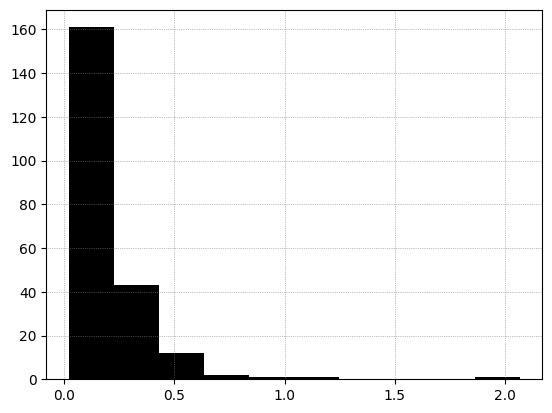

In [36]:
(annualElectricityDemandSI / annualHeatDemandSI).hist()

#### Electricity costs for the co-generation option
[back](#Table-of-contents)

The overall electricity costs comprise the cost for grid imports and the remuneration for electricity fed into the grid. 
With a guaranteed purchase obligation for electricity from micro combined heat and power generation under the stipulations made by the KWKG and EEG, the overall electricity costs are calculated as follows:
$$
\text{electricity cost} = \SpecificCosts{\SubElectrical} \int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time
    - \Fit{} \int_0^{\tau} \ElectricalPower[\SuperExports]{n} \dd \time 
$$

Denoting the electrical power demand (load) of an installation $n$ with $\ElectricalPower[\SuperDemand]{n}$ and the electrical power generated with $\ElectricalPower[\SuperCHP]{n}$, where $\ElectricalPower[\SuperDemand]{n}\geq 0$ and $\ElectricalPower[\SuperCHP]{n} \geq 0$, the grid imports are given by 
$$
\ElectricalPower[\SuperImports]{n} = 
\begin{cases}
    0 &\quad \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} \leq 0 \\
    \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} &\quad \text{otherwise}
\end{cases}
$$
an the grid exports by 
$$
\ElectricalPower[\SuperExports]{n} = 
\begin{cases}
    \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} &\quad \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} \leq 0 \\
    0 &\quad \text{otherwise}
\end{cases}
$$

##### Variant 1: Export fraction
[back](#Table-of-contents)

Using the power balance 
$$
\begin{aligned}
\ElectricalPower[\SuperImports]{n} + \ElectricalPower[\SuperCHP]{n} = 
    \ElectricalPower[\SuperDemand]{n} + \ElectricalPower[\SuperExports]{n} 
\end{aligned}
$$
the overall electricity costs may be rewritten as
$$
\begin{aligned}
\text{electricity cost} 
    = \SpecificCosts{\SubElectrical} \int_0^{\tau} \left( 
    \ElectricalPower[\SuperDemand]{n} 
        - \ElectricalPower[\SuperCHP]{n} \right) \dd \time 
    + \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) \int_0^{\tau} \ElectricalPower[\SuperExports]{n} \dd \time 
\end{aligned}
$$

> CHP-generated electricity is worth $\SpecificCosts{\SubElectrical}$ if it is used to offset demand. 
Excess production, that is, electricity fed into the grid, however, is worth only $\Fit{}$. 

Defining the export or feed-in fraction 
$$
\newcommand{\ExportFraction}[1]{f_{#1}}
%
\ExportFraction{n} := 
  \frac
    {\int_0^{\tau} \ElectricalPower[\SuperExports]{n} \dd \time}
    {\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time}
$$
we can rewrite the expression for electricity costs, such that
$$
\begin{aligned}
  \text{electricity cost} 
    &= \SpecificCosts{\SubElectrical} \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time
        - \left[ \SpecificCosts{\SubElectrical} - \ExportFraction{n} \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) 
    \right] \int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time \\
  \text{electricity cost savings} 
    &= \left[ \SpecificCosts{\SubElectrical} - \ExportFraction{n} \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) \right]
    \int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time 
\end{aligned}
$$

The export fraction $\ExportFraction{n}$ depends on the load profile and the control strategy. 
Minimizing $\ExportFraction{n}$ maximizes cost savings. 
Because 
$$
\begin{aligned}
0 \leq \int_0^{\tau} \ElectricalPower[\SuperImports]{n}  \dd \time  = 
    \int_0^{\tau} \left[ \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} + \ElectricalPower[\SuperExports]{n} \right]  \dd \time 
\end{aligned}
$$
it follows that
$$
\begin{aligned}
  \int_0^{\tau} \left[ \ElectricalPower[\SuperCHP]{n} - \ElectricalPower[\SuperDemand]{n} \right]  \dd \time  \leq \int_0^{\tau} \ElectricalPower[\SuperExports]{n} \dd \time 
\end{aligned}
$$
and
$$
\begin{aligned}
  1 - \frac{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time }{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time }  \leq \ExportFraction{n}
\end{aligned}
$$

Since $\ElectricalPower[\SuperExports]{n} \geq 0$, it is also true that
$$
0 \leq \ExportFraction{n}
$$

Hence 
$$
\max \left( 0, 1 - \frac{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time }{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time } \right) \leq \ExportFraction{n} \leq 1
$$

> The lower bound on $\ExportFraction{n}$ is zero when there is no net production, i.e. when $\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time \leq \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time$; otherwise it cannot be zero.

##### Variant 2: Degree of self-sufficiency
[back](#Table-of-contents)

Using the power balance 
$$
\begin{aligned}
\ElectricalPower[\SuperImports]{n} + \ElectricalPower[\SuperCHP]{n} = 
    \ElectricalPower[\SuperDemand]{n} + \ElectricalPower[\SuperExports]{n} 
\end{aligned}
$$
the overall electricity costs may be rewritten as
$$
\begin{aligned}
\text{electricity cost} 
    = \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) \int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time 
    + \Fit{} \int_0^{\tau} \left( \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} \right) \dd \time 
\end{aligned}
$$

Defining the degree of self-sufficiency
$$
\newcommand{\SelfSufficiency}[1]{s_{#1}}
%
\SelfSufficiency{n} := 
  1 - \frac
    {\int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time}
    {\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time}
$$
we can rewrite the expression for electricity costs, such that
$$
\begin{aligned}
  \text{electricity cost} 
    &= \left(1 - \SelfSufficiency{n}\right) \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time 
    + \Fit{} \int_0^{\tau} \left( \ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} \right) \dd \time  \\
    &= \left[\SpecificCosts{\SubElectrical} - \SelfSufficiency{n} \left( \SpecificCosts{\SubElectrical} - \Fit{} \right)\right] \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time - \Fit{} \int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time \\
  \text{electricity cost savings} &= \SelfSufficiency{n} \left( \SpecificCosts{\SubElectrical} - \Fit{} \right) \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time + \Fit{} \int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time
\end{aligned}
$$

Maximizing $\SelfSufficiency{n}$ maximizes cost savings. 
Trivially, because $0 \leq \ElectricalPower[\SuperImports]{n} \leq \ElectricalPower[\SuperDemand]{n}$
$$
0 \leq \SelfSufficiency{n} \leq 1
$$

Further, because
$$
\begin{aligned}
  0 &\leq \int_0^{\tau} \ElectricalPower[\SuperExports]{n} \dd \time 
        = \int_0^{\tau} \left(\ElectricalPower[\SuperCHP]{n} - \ElectricalPower[\SuperDemand]{n} + \ElectricalPower[\SuperImports]{n} \right) \dd \time \\
  \int_0^{\tau} \left(\ElectricalPower[\SuperDemand]{n} - \ElectricalPower[\SuperCHP]{n} \right) \dd \time 
      &\leq \int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time \\
  \left(1 - \frac{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time}{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time} \right) 
      &\leq \frac{\int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time}{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time} \\
  \SelfSufficiency{n} 
      &\leq \frac{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time}{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time}
\end{aligned}
$$

Hence 
$$
0 \leq \SelfSufficiency{n} \leq \min \left( 1, \frac{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time}{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time} \right)
$$

#### Electricity cost savings
[back](#Table-of-contents)

Let the thermal efficiency of the system defined as
$$
\ThermalEfficiency \coloneqq \frac{\ThermalPower{}}{\MolarFlowRate{\ce{CH4}}\ReactionEnthalpy[\SuperGross]{}}
$$
and the electrical efficiency defined as
$$
\ElectricalEfficiency \coloneqq  \frac{\ElectricalPower{}}{\MolarFlowRate{\ce{CH4}}\ReactionEnthalpy[\SuperGross]{}} 
$$

The power index is given by
$$
\PowerIndex \coloneqq \frac{\ElectricalEfficiency}{\ThermalEfficiency} = \frac{\ElectricalPower{}}{\ThermalPower{}}
$$

Assuming 
$$
\PowerIndex \approx const. \implies \ElectricalPower[\SuperCHP]{n} = \frac{\ThermalPower{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}
$$

Then
$$
\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time 
    = \int_0^{\tau} \frac{\ThermalPower{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}\dd \time
    = \frac{\ElectricalPower{\SubNominal}}{\ThermalPower{\SubNominal}} \AnnualHeatingDemand{n} 
    = \frac{\ElectricalEfficiency}{\ThermalEfficiency} \AnnualHeatingDemand{n}
$$

In [37]:
nominalPowerSI = 1e3
powerIndex = nominalPowerSI / NOMINAL_THERMAL_POWER_SI

annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]

annualElectricityProductionSI = (powerIndex * annualHeatDemandSI).rename(
    "annualElectricityProductionSI"
)
annualElectricityProductionSI.head()

AGENT
4     5.316368e+09
6     1.703202e+09
8     2.905450e+09
9     3.427633e+09
11    3.278625e+09
Name: annualElectricityProductionSI, dtype: float64

**Variant 1:**
$$
  \text{electricity cost savings} 
    = \left[ \SpecificCosts{\SubElectrical} - \ExportFraction{n} \left(\SpecificCosts{\SubElectrical} - \Fit{}\right) \right]
    \frac{\AnnualHeatingDemand{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}
$$
where 
$$
\max \left( 0, 1 - \frac{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time }{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time } \right) \leq \ExportFraction{n} \leq 1
$$

**Variant 2:**
$$
  \text{electricity cost savings} 
    = \SelfSufficiency{n} \left( \SpecificCosts{\SubElectrical} - \Fit{} \right) \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time + \Fit{} \frac{\AnnualHeatingDemand{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}
$$
where 
$$
0 \leq \SelfSufficiency{n} \leq \min \left( 1, \frac{\int_0^{\tau} \ElectricalPower[\SuperCHP]{n} \dd \time}{\int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time} \right)
$$

> *Conclusion:*
The second definition is more useful.
In the first variant, the lower bound depends on whether or not the installation produces a net surplus of electricity.
In the second variant, the upper bound depends on whether or not the net production is sufficiently high to allow for zero imports.
It is thereby irrelevant if the installation is a net producer or net consumer.
Assuming no net production of electricity and perfect demand matching (fn = 0, sn = Production/Demand) gives the same result. 

Assuming zero net electricity production, Variant 2 can be modified to introduce a factor $k$ to account for control efficiency. 
$$
\text{electricity cost savings} 
    = \left[ k \, \SpecificCosts{\SubElectrical} + (1 - k) \, \Fit{} \right] \frac{\AnnualHeatingDemand{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}
$$

Otherwise it would be
$$
\text{electricity cost savings} 
    = k \left( \SpecificCosts{\SubElectrical} - \Fit{} \right) \int_0^{\tau} \ElectricalPower[\SuperDemand]{n} \dd \time + \Fit{} \frac{\AnnualHeatingDemand{n}}{\ThermalPower{\SubNominal}} \ElectricalPower{\SubNominal}
$$

In [38]:
nominalPowerSI = 1e3
powerIndex = nominalPowerSI / NOMINAL_THERMAL_POWER_SI

annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]

annualElectricityProductionSI = (powerIndex * annualHeatDemandSI).rename(
    "annualElectricityProductionSI"
)
annualElectricityProductionSI.head()

mask = annualElectricityProductionSI <= annualElectricityDemandSI
count = sum(~mask)
total = len(mask)

Latex(
    rf"At $P_\mathrm{{N}} \leq {nominalPowerSI*1e-3}\,\mathrm{{kW}}$, {count}/{total} agents (${100*count/total:.2f} \%$) of the sample are net producers."
)

<IPython.core.display.Latex object>

In [39]:
annualElectricityDemandSI[~mask] / annualHeatDemandSI[~mask]

AGENT
4      0.059993
18     0.068320
50     0.056946
54     0.059309
88     0.071636
104    0.031881
125    0.070397
204    0.056963
208    0.020411
253    0.078121
257    0.070263
270    0.065239
283    0.079766
288    0.033026
302    0.053555
324    0.036216
346    0.054374
371    0.073496
372    0.066677
390    0.054988
393    0.043101
424    0.046676
430    0.076705
463    0.064582
467    0.037364
483    0.056194
488    0.061055
dtype: float64

It should be noted that the synthetic sample was generated from reported values for mean and standard deviation of the socio-demographic attributes without accounting for any cross-correlations between attributes, as these data were unavailable (see [Rommel and Sagebiel, 2017, Table 1](#References)).
Therefore, the relatively large share of potential net producers is presumably an artefact of the sample generation and unlikely to be realistic. 
Despite the absence of any cross-correlation data, it can still be assumed that socio-demographic and energy-related attributes such income, age, electricity costs, and living space (and thus heating requirements) are in fact highly correlated. 

In the following, both net consumer and potential net producers are considered to maintain generality. 

In [40]:
# annualHeatDemandSI[~mask].head()

In [41]:
(annualHeatDemandSI[~mask] >= annualHeatDemandSI.quantile(0.9)).sum()

np.int64(8)

In [42]:
(annualElectricityDemandSI[~mask] <= annualElectricityDemandSI.quantile(0.1)).sum()

np.int64(13)

In [43]:
# annualElectricityDemandSI[~mask].head()

In [44]:
nominalPowerSI = 2e3

annualElectricityProductionSI = (
    annualHeatDemandSI / NOMINAL_THERMAL_POWER_SI * nominalPowerSI
).rename("annualElectricityProductionSI")

mask = annualElectricityProductionSI <= annualElectricityDemandSI
count = sum(~mask)
total = len(mask)

Latex(
    rf"At $P_\mathrm{{N}} \leq {nominalPowerSI*1e-3}\,\mathrm{{kW}}$, {count}/{total} agents (${100*count/total:.2f} \%$) of the sample"
    rf"are net producers. That is ${total-count}/{total}$ (${100*(total-count)/total:.2f} \%$) are net producers"
)

<IPython.core.display.Latex object>

### Energy cost savings compared to status quo
[back](#Table-of-contents)

Hence
$$
\frac{\Csav[n]}{100} = \frac{1}{ \SpecificCosts{\mathrm{gas}} \AnnualHeatingDemand{n} / \ThermalEfficiency[\SuperStatusQuo]{} + \SpecificCosts{\SubElectrical} \, \AnnualElectricityDemand{n} } \left[
    \SpecificCosts{\mathrm{gas}} \AnnualHeatingDemand{n} \left(
    \frac{1}{\ThermalEfficiency[\SuperStatusQuo]} - \frac{1}{\ThermalEfficiency[\SuperCHP]}
    \right) \right. + \\
    \left. 
      \SpecificCosts{\SubElectrical} \SelfSufficiency{n}  \AnnualElectricityDemand{n} 
      + \Fit{}
       \left( 
        \frac{\ElectricalEfficiency[\SuperCHP]{}}{\ThermalEfficiency[\SuperCHP]{}} \AnnualHeatingDemand{n} 
        - \SelfSufficiency{n} \AnnualElectricityDemand{n} 
      \right) 
    % \right]
\right]
$$
with 
$$
\begin{aligned}
  \frac{1}{\ThermalEfficiency[\SuperCHP]} 
      = \frac{\ReactionEnthalpy[\SuperGross]{}}{\ThermalPower{\SubNominal}} \,\MolarFlowRate{\ce{CH4}} 
  \quad \text{and} \quad
  \frac{\ElectricalEfficiency[\SuperCHP]}{\ThermalEfficiency[\SuperCHP]} 
      = \frac{\ElectricalPower{\SubNominal}}{\ThermalPower{\SubNominal}}
\end{aligned}
$$

In [45]:
from phdtools.optimization.preprocessing import energyCostSavingsModel

thermalEfficiency = 0.9
nominalPowerSI = 1e3

powerIndex = nominalPowerSI / NOMINAL_THERMAL_POWER_SI
matchingFactor = 0.5

energyCostSavings = energyCostSavingsModel(
    thermalEfficiency=thermalEfficiency,
    powerIndex=powerIndex,
    matchingFactor=matchingFactor,
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ),
)

energyCostSavings.droplevel("ALTERNATIVE")

AGENT
4      0.178750
6      0.111290
8      0.131418
9      0.161897
11     0.138767
         ...   
500    0.144530
502    0.136547
506    0.152303
508    0.186861
511    0.179705
Length: 221, dtype: float64

In [46]:
from phdtools.stats import ecdf

data_id = DataID(DataType.FIGURE, Chapter.METHODS, 7)


@auto_create_path
def save_ecdf_energy_cost_savings(
    path,
    thermalEfficiency,
    nominalThermalPowerSI,
    nominalPowerSI,
    matchingFactor,
    sample_sizes=[16, 32, 64, 128, 256, 512, 1024],
):

    if os.path.exists(path / f"{FILE_DATE}_sample_sizes.csv") and overwrite:
        os.remove(path / f"{FILE_DATE}_sample_sizes.csv")

    for sample_size in sample_sizes:
        fname_s = (
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        _record_sample_sizes(
            infile=fname_s, outfile=path / f"{FILE_DATE}_sample_sizes.csv"
        )

        powerIndex = nominalPowerSI / nominalThermalPowerSI

        energyCostSavings = energyCostSavingsModel(
            thermalEfficiency=thermalEfficiency,
            powerIndex=powerIndex,
            matchingFactor=matchingFactor,
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE}_annual_heating_demands_{sample_size}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE}_annual_electricity_demands_{sample_size}.csv"
            ),
        )

        energyCostSavings = energyCostSavings.droplevel("ALTERNATIVE")

        x, y = ecdf(energyCostSavings)

        description = (
            "Energy cost savings relative to status quo (conditional on HEATSYS = 1).\n\n"
            "Assuming: \n"
            f"  thermal efficiency: {thermalEfficiency}\n"
            f"  nominal th. power: {nominalThermalPowerSI/1000} kW\n"
            f"  nominal el. power: {nominalPowerSI/1000} kW\n"
            f"  matching factor: {matchingFactor}\n\n"
            "The annual heating demands are given in\n"
            f'    "RESULTS_DIR/{(DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                    / f"{FILE_DATE}_annual_heating_demands_{sample_size}.csv").relative_to(RESULTS_DIR)}"\n'
            "\n"
            "The annual electricity demands are given in\n"
            f'    "RESULTS_DIR/{(DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                        / f"{FILE_DATE}_annual_electricity_demands_{sample_size}.csv").relative_to(RESULTS_DIR)}"\n'
            "\n"
            "The socio-demographic attributes are given in\n"
            f'    "RESULTS_DIR/{fname_s.relative_to(RESULTS_DIR)}"\n'
            "\n"
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "  Germany: Policy implications for grid expansion from a discrete choice\n"
            "  experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "  https://doi.org/10.1016/j.apenergy.2017.08.216.\n\n"
        )

        fname = path / f"{TODAY}_ecdf_energy_cost_savings_{sample_size}.csv"
        with open(fname, "w") as f:
            write_metadata(f, description=description)
            np.savetxt(
                f,
                np.c_[energyCostSavings.sort_values().index, x, y],
                header='"AGENT","energyCostSavings","ECDF"',
                delimiter=",",
                comments="",
            )


save_ecdf_energy_cost_savings(
    data_id,
    thermalEfficiency=0.9,
    nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    nominalPowerSI=1e3,
    matchingFactor=0.5,
    doc=(
        r"Energy cost savings relative to status quo across the sample for given values of thermal efficiency"
        r" and nominal electrical power (conditional on $\mathrm{HEATSYS} = 1$); see \textcite{Rommel.2017a}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/kQKfTe' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [47]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 7).get_path(fail_exists=False)}

260319_ecdf_energy_cost_savings_1024.csv
260319_ecdf_energy_cost_savings_128.csv
260319_ecdf_energy_cost_savings_16.csv
260319_ecdf_energy_cost_savings_256.csv
260319_ecdf_energy_cost_savings_32.csv
260319_ecdf_energy_cost_savings_512.csv
260319_ecdf_energy_cost_savings_64.csv
260319_sample_sizes.csv


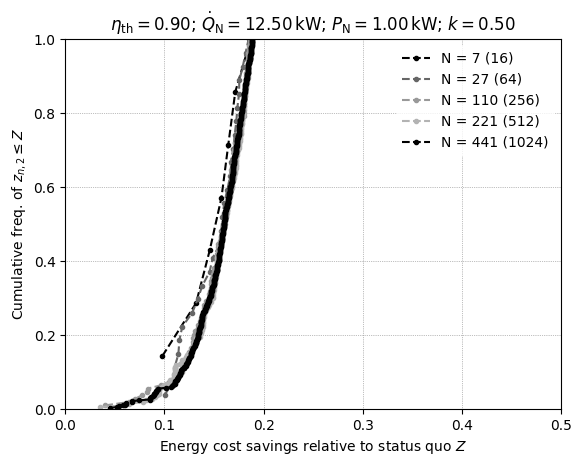

In [48]:
from phdtools.plots.optimization.preprocessing import (
    plot_energy_cost_savings_across_sample,
)

_ = plot_energy_cost_savings_across_sample(
    thermalEfficiency=0.9,
    nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    nominalPowerSI=1e3,
    matchingFactor=0.5,
    fnames={
        sample_size: (
            DataID(DataType.FIGURE, Chapter.METHODS, 7).get_path(fail_exists=False)
            / f"{FILE_DATE}_ecdf_energy_cost_savings_{sample_size}.csv"
        )
        for sample_size in [16, 64, 256, 512, 1024]
    },
)

## CO2 savings
[back](#Table-of-contents)

### CO2 emissions for the status-quo option
[back](#Table-of-contents)

For the satus quo option, $\ce{CO2}$ emissions come from heating and electricity production. 
Assuming complete oxidation

$$
\newcommand{\EmissionFactor}[1]{f_{#1}}
\MolarFlowRate[\SuperStatusQuo]{\ce{CO2},\mathrm{out}} = \MolarFlowRate[\SuperStatusQuo]{\ce{CH4},\mathrm{in}} 
\implies 
\TotalAmountOfSubstance[\SuperStatusQuo]{\ce{CO2}} 
    = \int_0^{\tau} \MolarFlowRate[\SuperStatusQuo]{\ce{CO2},n} \dd \time 
    + \EmissionFactor{\ce{CO2}} \int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time 
$$

where $\EmissionFactor{\ce{CO2}} = 433\,\mathrm{g({\ce{CO2}})\,/\,kW\,h}$ are the direct $\ce{CO2}$ emissions per unit energy resulting from the combustion of fossil fuels during the generation of electricity according to ther German energy mix, referred to as the emission factor [(see Icha and Lauf, 2025)](#References). 

With
$$
\ThermalEfficiency[\SuperStatusQuo] 
    \coloneqq \frac{\ThermalPower[\SuperStatusQuo]{}}{\MolarFlowRate{\ce{CH4}}\ReactionEnthalpy[\SuperGross]{}} 
    = \frac{\ReactionEnthalpy[\SuperNet]{}}{\ReactionEnthalpy[\SuperGross]{}} \frac{\ThermalPower[\SuperStatusQuo]{}}{\MolarFlowRate{\ce{CH4}}\ReactionEnthalpy[\SuperNet]{}} 
    = \frac{\ReactionEnthalpy[\SuperNet]{}}{\ReactionEnthalpy[\SuperGross]{}} \BoilerEfficiency
$$
and $\ElectricalPower[\SuperImports]{n} = \ElectricalPower[\SuperDemand]{n}$
we yield
$$
\ce{CO2} \ \text{emissions (SQ)} = \frac{\AnnualHeatingDemand{n}}{\ThermalEfficiency[\SuperStatusQuo] \ReactionEnthalpy[\SuperGross]{}} + \EmissionFactor{\ce{CO2}} \AnnualElectricityDemand{n} 
$$

### CO2 emissions for the co-generation option
[back](#Table-of-contents)

The CO₂ emissions associated with the combined heat and power option include emissions caused by the combined heat and power plant itself and emissions attributable to covering the remaining electricity demand. 

Hence, it follows from the definition of self sufficiency $\SelfSufficiency{n}$, see [§ Electricity cost savings](#Electricity-cost-savings)), that
$$
\TotalAmountOfSubstance[\SuperCHP]{\ce{CO2}} 
    = \frac{\AnnualHeatingDemand{n}}{\ThermalEfficiency[\SuperCHP] \ReactionEnthalpy[\SuperGross]{}} + \EmissionFactor{\ce{CO2}} \underbrace{(1 - \SelfSufficiency{n}) \AnnualElectricityDemand{n}}_{\int_0^{\tau} \ElectricalPower[\SuperImports]{n} \dd \time }
$$

In [49]:
from phdtools.optimization import GROSS_CALORIFIC_VALUE_METHANE_SI

thermalEfficiency = 0.9

annualHeatDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualHeatDemandSI"]


-1 * annualHeatDemandSI / (thermalEfficiency * GROSS_CALORIFIC_VALUE_METHANE_SI)

AGENT
4      82848.795577
6      26542.232576
8      45277.722935
9      53415.273511
11     51093.185171
           ...     
500    37871.765455
502    53326.550192
506    68760.362678
508    46822.441932
511    69367.622750
Name: annualHeatDemandSI, Length: 221, dtype: float64

In [50]:
from phdtools.optimization import CO2_EMISSION_FACTOR_MOL_PER_KWH

annualElectricityDemandSI = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)["annualElectricityDemandSI"]

(CO2_EMISSION_FACTOR_MOL_PER_KWH * 1e-3 / 3600) * annualElectricityDemandSI

AGENT
4      10895.856100
6      22849.310490
8      27379.425406
9      18057.751859
11     27064.060396
           ...     
500    18034.912082
502    29409.894858
506    28225.003564
508     8637.029231
511    15547.378124
Name: annualElectricityDemandSI, Length: 221, dtype: float64

### CO2 savings compared to status quo
[back](#Table-of-contents)

In addition, further (external) savings are achieved when the electricity from combined heat and power co-generation is fed into the grid, thereby improving the $\ce{CO2}$ intensity of the electricity mix. 
Since the exported electricity does not require produce additional emissions beyond the emissions attributed to the heating function, the annual $\ce{CO2}$ emission savings from grid exports are

$$
\begin{align}
  \Delta \TotalAmountOfSubstance[\SuperExports]{\ce{CO2}} 
    = \EmissionFactor{\ce{CO2}} \int_0^{\tau} \ElectricalPower[\SuperExports]{n}(\time{}) \, \dd \time{} 
\end{align}
$$

From the definition of self-sufficiency
$$
\int_0^{\tau} \ElectricalPower[\SuperImports]{n}(\time{}) \, \dd \time{} = \left(1 - \SelfSufficiency{n} \right) \AnnualElectricityDemand{n}
$$

Because
$$
\ElectricalPower[\SuperExports]{n} = \ElectricalPower[\SuperImports]{n} + \ElectricalPower{n} -  \ElectricalPower[\SuperDemand]{n}
$$
we find
$$
\begin{aligned}
  \int_0^{\tau} \ElectricalPower[\SuperExports]{n}(\time{}) \, \dd\time{}  
    &= \int_0^{\tau} \ElectricalPower{n}(\time{}) \, \dd \time{} - \SelfSufficiency{n} \AnnualElectricityDemand{n} \\
    &= \frac{\ElectricalEfficiency[\SuperCHP]}{\ThermalEfficiency[\SuperCHP]}  \AnnualHeatingDemand{n} - \SelfSufficiency{n} \AnnualElectricityDemand{n} 
\end{aligned}
$$
Hence, 
$$
\begin{aligned}
  \Delta \TotalAmountOfSubstance[\SuperExports]{\ce{CO2}} 
    = \EmissionFactor{\ce{CO2}} \left[ \frac{\ElectricalEfficiency[\SuperCHP]}{\ThermalEfficiency[\SuperCHP]}  \AnnualHeatingDemand{n} - \SelfSufficiency{n} \right]
\end{aligned}
$$

In summary
$$
\frac{\CoTwoSav[n]}{10} 
    = \frac{%
        1}{%
        \AnnualHeatingDemand{n} / \left(\ThermalEfficiency[\SuperStatusQuo] \ReactionEnthalpy[\SuperGross]{\mathrm{MC}}\right) 
        + \EmissionFactor{\ce{CO2}} \AnnualElectricityDemand{n}
        } \times \\
      \left[ 
        \frac{\AnnualHeatingDemand{n}}{\ReactionEnthalpy[\SuperGross]{\mathrm{MC}}}
        \left(
          \frac{1}{\ThermalEfficiency[\SuperStatusQuo]} 
          - \frac{1}{\ThermalEfficiency[\SuperCHP]}
        \right)
      +
        \EmissionFactor{\ce{CO2}}
        \frac
          {\ElectricalEfficiency[\SuperCHP]}
          {\ThermalEfficiency[\SuperCHP]} 
          \AnnualHeatingDemand{n} 
      \right]
$$
with 
$$
\begin{aligned}
  \frac{1}{\ThermalEfficiency[\SuperCHP]} 
      = \frac{\ReactionEnthalpy[\SuperGross]{}}{\ThermalPower{\SubNominal}} \,\MolarFlowRate{\ce{CH4}} 
  \quad \text{and} \quad
  \frac{\ElectricalEfficiency[\SuperCHP]}{\ThermalEfficiency[\SuperCHP]} 
      = \frac{\ElectricalPower{\SubNominal}}{\ThermalPower{\SubNominal}}
\end{aligned}
$$

In [51]:
from phdtools.optimization.preprocessing import carbonDioxideEmissionReductionsModel

thermalEfficiency = 0.9
nominalPowerSI = 1e3

carbonDioxideEmissionReductions = carbonDioxideEmissionReductionsModel(
    thermalEfficiency=thermalEfficiency,
    powerIndex=powerIndex,
    fname_heat=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_heating_demands_{NUM_AGENTS}.csv"
    ),
    fname_electricity=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
        / f"{FILE_DATE}_annual_electricity_demands_{NUM_AGENTS}.csv"
    ),
)
carbonDioxideEmissionReductions.droplevel("ALTERNATIVE")

AGENT
4      0.230308
6      0.145110
8      0.166779
9      0.197474
11     0.174404
         ...   
500    0.180283
502    0.172117
506    0.188072
508    0.220893
511    0.214329
Length: 221, dtype: float64

In [52]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 8)


@auto_create_path
def save_ecdf_carbon_dioxide_savings(
    path,
    thermalEfficiency,
    nominalThermalPowerSI,
    nominalPowerSI,
    sample_sizes=[16, 32, 64, 128, 256, 512, 1024],
):

    if os.path.exists(path / f"{FILE_DATE}_sample_sizes.csv") and overwrite:
        os.remove(path / f"{FILE_DATE}_sample_sizes.csv")

    for sample_size in sample_sizes:
        fname_s = (
            DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        _record_sample_sizes(
            infile=fname_s, outfile=path / f"{FILE_DATE}_sample_sizes.csv"
        )

        powerIndex = nominalPowerSI / nominalThermalPowerSI

        carbonDioxideEmissionReductions = carbonDioxideEmissionReductionsModel(
            thermalEfficiency=thermalEfficiency,
            powerIndex=powerIndex,
            fname_heat=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                / f"{FILE_DATE}_annual_heating_demands_{sample_size}.csv"
            ),
            fname_electricity=(
                DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                / f"{FILE_DATE}_annual_electricity_demands_{sample_size}.csv"
            ),
        )
        carbonDioxideEmissionReductions = carbonDioxideEmissionReductions.droplevel(
            "ALTERNATIVE"
        )

        x, y = ecdf(carbonDioxideEmissionReductions)

        description = (
            "Carbon dioxide emissions reductions relative to status quo (conditional on HEATSYS = 1).\n\n"
            "Assuming: \n"
            f"  thermal efficiency: {thermalEfficiency}\n"
            f"  nominal th. power: {nominalThermalPowerSI/1000} kW\n"
            f"  nominal el. power: {nominalPowerSI/1000} kW\n"
            "The annual heating demands are given in\n"
            f'    "RESULTS_DIR/{(DataID(DataType.SUPPORT, Chapter.METHODS, 4).get_path(fail_exists=False)
                    / f"{FILE_DATE}_annual_heating_demands_{sample_size}.csv").relative_to(RESULTS_DIR)}"\n'
            "\n"
            "The annual electricity demands are given in\n"
            f'    "RESULTS_DIR/{(DataID(DataType.SUPPORT, Chapter.METHODS, 5).get_path(fail_exists=False)
                        / f"{FILE_DATE}_annual_electricity_demands_{sample_size}.csv").relative_to(RESULTS_DIR)}"\n'
            "\n"
            "The socio-demographic attributes are given in\n"
            f'    "RESULTS_DIR/{fname_s.relative_to(RESULTS_DIR)}"\n'
            "\n"
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "  Germany: Policy implications for grid expansion from a discrete choice\n"
            "  experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "  https://doi.org/10.1016/j.apenergy.2017.08.216.\n\n"
        )

        fname = path / f"{TODAY}_ecdf_carbon_dioxide_savings_{sample_size}.csv"
        with open(fname, "w") as f:
            write_metadata(f, description=description)
            np.savetxt(
                f,
                np.c_[carbonDioxideEmissionReductions.sort_values().index, x, y],
                header='"AGENT","energyCostSavings","ECDF"',
                delimiter=",",
                comments="",
            )


save_ecdf_carbon_dioxide_savings(
    data_id,
    thermalEfficiency=0.9,
    nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    nominalPowerSI=1e3,
    doc=(
        r"Carbon dioxide emissions reduction relative to status quo across the sample for given values of thermal efficiency"
        r" and nominal electrical power (conditional on $\mathrm{HEATSYS} = 1$); see \textcite{Rommel.2017a}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/FLGPXV' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [53]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 8).get_path(fail_exists=False)}

260319_ecdf_carbon_dioxide_savings_1024.csv
260319_ecdf_carbon_dioxide_savings_128.csv
260319_ecdf_carbon_dioxide_savings_16.csv
260319_ecdf_carbon_dioxide_savings_256.csv
260319_ecdf_carbon_dioxide_savings_32.csv
260319_ecdf_carbon_dioxide_savings_512.csv
260319_ecdf_carbon_dioxide_savings_64.csv
260319_sample_sizes.csv


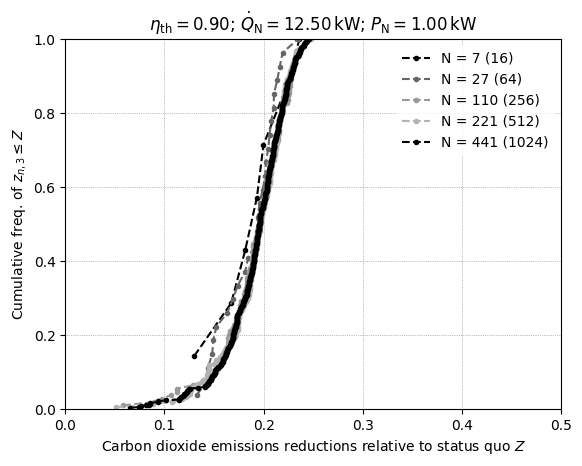

In [54]:
from phdtools.plots.optimization.preprocessing import (
    plot_carbon_dioxide_savings_across_sample,
)

_ = plot_carbon_dioxide_savings_across_sample(
    thermalEfficiency=0.9,
    nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    nominalPowerSI=1e3,
    fnames={
        sample_size: (
            DataID(DataType.FIGURE, Chapter.METHODS, 8).get_path(fail_exists=False)
            / f"{FILE_DATE}_ecdf_carbon_dioxide_savings_{sample_size}.csv"
        )
        for sample_size in [16, 64, 256, 512, 1024]
    },
)

## Product demand contour
[back](#Table-of-contents)

In [55]:
from phdtools.optimization import (
    INVESTMENT_TYPE,
    CONTRACT_DURATION_YEARS,
    FEED_IN_TARIFF_EUR_PER_KWH,
)
from phdtools.optimization.preprocessing import get_attributes_alternative

In [56]:
from itertools import product

priceEuro = np.arange(1e4, 2.1e4, 1e3)
thermalEfficiency = np.arange(0.75, 0.95, 0.01)
powerIndex = np.array([1e3]) / NOMINAL_THERMAL_POWER_SI
matchingFactor = np.array([0.5])

designs = pd.DataFrame(
    product(priceEuro, thermalEfficiency, powerIndex, matchingFactor),
    columns=["PRICE_EURO", "THERMAL_EFFICIENCY", "POWER_INDEX", "MATCHING_FACTOR"],
)
designs.index.name = "ALTERNATIVE"
designs.head()

,PRICE_EURO,THERMAL_EFFICIENCY,POWER_INDEX,MATCHING_FACTOR
ALTERNATIVE,,,,
0,10000.0,0.75,0.08,0.5
1,10000.0,0.76,0.08,0.5
2,10000.0,0.77,0.08,0.5
3,10000.0,0.78,0.08,0.5
4,10000.0,0.79,0.08,0.5


In [57]:
attributes_alternative = get_attributes_alternative(
    designs,
    data_id_socio_demographic_attributes=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
    data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
    file_date=FILE_DATE,
    file_date_agents=FILE_DATE_AGENTS,
    sample_size=NUM_AGENTS,
    # nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    fit=100 * FEED_IN_TARIFF_EUR_PER_KWH,
    itype=INVESTMENT_TYPE,
    dur=CONTRACT_DURATION_YEARS,
)

attributes_alternative

,,ICOST,CSAV,CO2SAV,FIT,ITYPE,DUR
AGENT,ALTERNATIVE,,,,,,
4,0,13.0,2.379555,0.693079,8.0,0,5
6,0,13.0,2.390838,0.436688,8.0,0,5
8,0,13.0,2.823259,0.501899,8.0,0,5
9,0,13.0,3.478023,0.594269,8.0,0,5
11,0,13.0,2.981119,0.524846,8.0,0,5
...,...,...,...,...,...,...,...
500,219,26.0,16.867499,2.070978,8.0,0,5
502,219,26.0,15.935792,1.977167,8.0,0,5
506,219,26.0,17.774643,2.160458,8.0,0,5


In [58]:
from phdtools.models.rommel_sagebiel_2017 import (
    compute_sample_avg_mxl_prob,
    compute_sample_avg_logit_prob,
)

sample_average_mxl_probabilities = compute_sample_avg_mxl_prob(
    attributes_alternative,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE_SAMPLE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE_SAMPLE}_random_coefficients_{MXL_COEFS_SMAPLE_SIZE}.csv",
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
)

sample_average_logit_probabilities = compute_sample_avg_logit_prob(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE_REGRESSION}_logit_coefficients.json",
)

In [59]:
from phdtools.plots.export import write_contour_lines

In [60]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 9)


@auto_create_path
def save_expected_market_share_contour(
    path,
    nominalThermalPowerSI,
    nominalPowerSI,
    data_id_sample,
    data_id_random_coefs,
    data_id_logit_coefs,
    levels=[0.45, 0.48, 0.5, 0.53, 0.55, 0.58],
    sample_sizes=[16, 32, 64, 128, 256, 512, 1024],
):

    priceEuro = np.arange(1e4, 2.05e4, 0.5e3)
    thermalEfficiency = np.arange(0.75, 0.96, 0.01)
    powerIndex = np.array([nominalPowerSI]) / NOMINAL_THERMAL_POWER_SI
    matchingFactor = np.array([0.5])

    designs = pd.DataFrame(
        product(priceEuro, thermalEfficiency, powerIndex, matchingFactor),
        columns=["PRICE_EURO", "THERMAL_EFFICIENCY", "POWER_INDEX", "MATCHING_FACTOR"],
    )
    designs.index.name = "ALTERNATIVE"

    if os.path.exists(path / f"{FILE_DATE}_sample_sizes.csv") and overwrite:
        os.remove(path / f"{FILE_DATE}_sample_sizes.csv")

    for sample_size in sample_sizes:

        fname_sample = (
            data_id_sample.get_path(fail_exists=False)
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv"
        )

        fname_random_coefs = (
            data_id_random_coefs.get_path(fail_exists=False)
            / f"{FILE_DATE_SAMPLE}_random_coefficients_{MXL_COEFS_SMAPLE_SIZE}.csv"
        )

        fname_logit_coefs = (
            data_id_logit_coefs.get_path(fail_exists=False)
            / f"{FILE_DATE_REGRESSION}_logit_coefficients.json"
        )

        _record_sample_sizes(
            infile=fname_sample, outfile=path / f"{FILE_DATE}_sample_sizes.csv"
        )

        attributes_alternative = get_attributes_alternative(
            designs,
            data_id_socio_demographic_attributes=DataID(
                DataType.SUPPORT, Chapter.METHODS, 1
            ),
            data_id_heating_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 4),
            data_id_electricity_demands=DataID(DataType.SUPPORT, Chapter.METHODS, 5),
            file_date=FILE_DATE,
            file_date_agents=FILE_DATE_AGENTS,
            sample_size=sample_size,
            # nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
            fit=100 * FEED_IN_TARIFF_EUR_PER_KWH,
            itype=INVESTMENT_TYPE,
            dur=CONTRACT_DURATION_YEARS,
        )

        sample_average_mxl_probabilities = compute_sample_avg_mxl_prob(
            attributes_alternative,
            fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_SAMPLE}_deterministic_coefficients.csv",
            fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_SAMPLE}_random_coefficients_{MXL_COEFS_SMAPLE_SIZE}.csv",
            fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv",
        )

        sample_average_logit_probabilities = compute_sample_avg_logit_prob(
            attributes_alternative,
            fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_AGENTS}_socio_demographic_attributes_{sample_size}.csv",
            fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(
                fail_exists=False
            )
            / f"{FILE_DATE_REGRESSION}_logit_coefficients.json",
        )

        frame = pd.concat(
            [
                designs,
                sample_average_mxl_probabilities,
                sample_average_logit_probabilities,
            ],
            axis=1,
        )
        mask = (np.isclose(frame["POWER_INDEX"], 1e3 / NOMINAL_THERMAL_POWER_SI)) & (
            np.isclose(frame["MATCHING_FACTOR"], 0.5)
        )

        description = (
            "Sample average choice probability according to\n"
            "a mixed logit model by Rommel and Sagebiel (2017).\n"
            "Probabilities computed over different values of price and thermal efficiency\n"
            f"with the power index assumed constant (powerIndex = {nominalPowerSI/NOMINAL_THERMAL_POWER_SI}).\n"
            f"The power index is given by the ratio of nominal (electrical) power ({nominalPowerSI/1000} kW)\n"
            f"and nominal thermal power ({nominalThermalPowerSI/1000} kW).\n"
            "The results are based on an synthetic sample of decision makers\n"
            "characterized by socio-demographic attributes and realizations of\n"
            "the random coefficients to compute the mean probability for every\n"
            "decision-maker.\n\n"
            "The random coeficients are given in\n\n"
            '    "RESULTS_DIR/{}"\n\n'.format(
                fname_random_coefs.relative_to(RESULTS_DIR)
            )
            + "The socio-demographic attributes are given in\n\n"
            '    "RESULTS_DIR/{}"\n\n'.format(fname_sample.relative_to(RESULTS_DIR))
            + (
                "\n"
                "References:\n"
                "-----------\n"
                "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
                "    Germany: Policy implications for grid expansion from a discrete choice\n"
                "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
                "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
            )
        )

        fname = path / f"{TODAY}_expected_market_share_mxl_{sample_size}_raw.csv"
        with open(fname, "w+") as f:
            write_metadata(f, description)
            frame[mask].drop(
                ["POWER_INDEX", "MATCHING_FACTOR", "SAMPLE_AVG_LOGIT_PROB"], axis=1
            ).rename(columns={"SAMPLE_AVG_MXL_PROB": "SAMPLE_AVG_PROB"}).to_csv(f)

        fname = (
            path
            / f"{TODAY}_expected_market_share_mxl_{sample_size}_contour_prepared.dat"
        )
        with open(fname, "w+") as f:
            tmp = frame[mask].pivot(
                index="THERMAL_EFFICIENCY",
                columns="PRICE_EURO",
                values="SAMPLE_AVG_MXL_PROB",
            )
            x = tmp.columns.to_numpy()
            y = tmp.index.to_numpy()
            Z = tmp.to_numpy()
            write_metadata(
                f,
                description=f"Contour lines for raw data {path / f"{TODAY}_expected_market_share_mxl_{sample_size}_raw.csv"}",
            )
            write_contour_lines(f, x, 1 / y, Z, levels=levels)

        # Logit approximation
        description = (
            "Sample average choice probability according to the\n"
            "logit approximation of Rommel and Sagebiel (2017).\n"
            "Probabilities computed over different values of price and thermal efficiency\n"
            f"with the power index assumed constant (powerIndex = {powerIndex}).\n"
            f"The power index is given by the ratio of nominal (electrical) power ({nominalPowerSI/1000} kW)\n"
            f"and nominal thermal power ({nominalThermalPowerSI/1000} kW).\n"
            "The results are based on a synthetic sample of decision makers\n"
            "characterized by socio-demographic attributes and approximated\n"
            "logit coefficients.\n\n"
            "The logit coeficients are given in\n\n"
            '    "RESULTS_DIR/{}"\n\n'.format(
                fname_logit_coefs.relative_to(RESULTS_DIR)
            )
            + "The socio-demographic attributes are given in\n\n"
            '    "RESULTS_DIR/{}"\n\n'.format(fname_sample.relative_to(RESULTS_DIR))
            + (
                "\n"
                "References:\n"
                "-----------\n"
                "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
                "    Germany: Policy implications for grid expansion from a discrete choice\n"
                "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
                "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
            )
        )

        fname = path / f"{TODAY}_expected_market_share_logit_{sample_size}_raw.csv"
        with open(fname, "w+") as f:
            write_metadata(f, description)
            frame[mask].drop(
                ["POWER_INDEX", "MATCHING_FACTOR", "SAMPLE_AVG_MXL_PROB"], axis=1
            ).rename(columns={"SAMPLE_AVG_LOGIT_PROB": "SAMPLE_AVG_PROB"}).to_csv(f)

        fname = (
            path
            / f"{TODAY}_expected_market_share_logit_{sample_size}_contour_prepared.dat"
        )
        with open(fname, "w+") as f:
            tmp = frame[mask].pivot(
                index="THERMAL_EFFICIENCY",
                columns="PRICE_EURO",
                values="SAMPLE_AVG_LOGIT_PROB",
            )
            x = tmp.columns.to_numpy()
            y = tmp.index.to_numpy()
            Z = tmp.to_numpy()
            write_metadata(
                f,
                description=f"Contour lines for raw data {path / f"{TODAY}_expected_market_share_mxl_{sample_size}_raw.csv"}",
            )
            write_contour_lines(f, x, 1 / y, Z, levels=levels)


save_expected_market_share_contour(
    data_id,
    nominalThermalPowerSI=NOMINAL_THERMAL_POWER_SI,
    nominalPowerSI=1e3,
    data_id_sample=DataID(DataType.SUPPORT, Chapter.METHODS, 1),
    data_id_random_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 2),
    data_id_logit_coefs=DataID(DataType.SUPPORT, Chapter.METHODS, 3),
    doc=(
        r"Expected market share for given values of thermal efficiency and power index"
        r" with the choice probabilities determined according to \textcite{Rommel.2017a}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/Documents/git/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-tools-dev/phd-results/XMbmb9' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [61]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 9).get_path(fail_exists=False)}

260319_expected_market_share_logit_1024_contour_prepared.dat
260319_expected_market_share_logit_1024_raw.csv
260319_expected_market_share_logit_128_contour_prepared.dat
260319_expected_market_share_logit_128_raw.csv
260319_expected_market_share_logit_16_contour_prepared.dat
260319_expected_market_share_logit_16_raw.csv
260319_expected_market_share_logit_256_contour_prepared.dat
260319_expected_market_share_logit_256_raw.csv
260319_expected_market_share_logit_32_contour_prepared.dat
260319_expected_market_share_logit_32_raw.csv
260319_expected_market_share_logit_512_contour_prepared.dat
260319_expected_market_share_logit_512_raw.csv
260319_expected_market_share_logit_64_contour_prepared.dat
260319_expected_market_share_logit_64_raw.csv
260319_expected_market_share_mxl_1024_contour_prepared.dat
260319_expected_market_share_mxl_1024_raw.csv
260319_expected_market_share_mxl_128_contour_prepared.dat
260319_expected_market_share_mxl_128_raw.csv
260319_expected_market_share_mxl_16_contour_pre

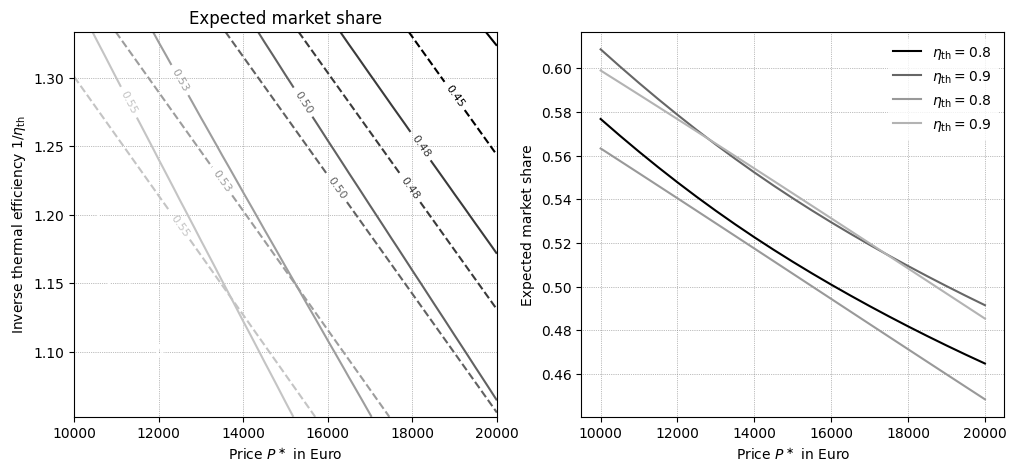

In [62]:
def plot_expected_market_share_contour(
    fnames, levels=[0.45, 0.48, 0.5, 0.53, 0.55, 0.58]
):

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    linestyles = ["-", "--", "dotted"]
    for num, fname in enumerate(fnames):
        frame = pd.read_csv(fname, comment="#", index_col=0)

        df = frame.pivot(
            index="THERMAL_EFFICIENCY", columns="PRICE_EURO", values="SAMPLE_AVG_PROB"
        )

        x = df.columns.to_numpy()
        y = df.index.to_numpy()
        Z = df.to_numpy()

        cs = axs[0].contour(x, 1 / y, Z, levels=levels, linestyles=linestyles[num])

        axs[0].clabel(cs, inline=True, fontsize=8, fmt="%.2f")

        for thermalEfficiency in [0.8, 0.9]:
            mask = np.isclose(frame["THERMAL_EFFICIENCY"], thermalEfficiency)
            axs[1].plot(
                frame[mask]["PRICE_EURO"],
                frame[mask]["SAMPLE_AVG_PROB"],
                "-",
                label=rf"$\eta_\mathrm{{th}} = {thermalEfficiency}$",
            )

        # cs_list.append(_tmp.copy())

    axs[0].set_title(r"Expected market share")
    axs[0].set_xlabel(r"Price $P^\ast$ in Euro")
    axs[0].set_ylabel(r"Inverse thermal efficiency $1/\eta_\mathrm{th}$")

    # axs[0].set_title(r"Expected market share")
    axs[1].set_xlabel(r"Price $P^\ast$ in Euro")
    axs[1].set_ylabel("Expected market share")
    axs[1].legend()

    for ax in axs:
        ax.grid()

    return fig


fig = plot_expected_market_share_contour(
    fnames=[
        DataID(DataType.FIGURE, Chapter.METHODS, 9).get_path(fail_exists=False)
        / f"{FILE_DATE}_expected_market_share_mxl_512_raw.csv",
        DataID(DataType.FIGURE, Chapter.METHODS, 9).get_path(fail_exists=False)
        / f"{FILE_DATE}_expected_market_share_logit_16_raw.csv",
    ]
)

## References
[back](#Table-of-contents)

1. Rommel, K. and Sagebiel, J. (2017) “Preferences for micro-cogeneration in Germany: Policy implications for grid expansion from a discrete choice experiment,” Applied Energy, 206, pp. 612–622. Available at: https://doi.org/10.1016/j.apenergy.2017.08.216.
2. European Commission (2015) Commission Delegated Regulation (EU) 2015/2402 of 12 October 2015 reviewing harmonised efficiency reference values for separate production of electricity and heat in application of Directive 2012/27/EU of the European Parliament and of the Council and repealing Commission Implementing Decision 2011/877/EU. Available at: http://data.europa.eu/eli/reg_del/2015/2402/oj.
3. Kemmler, A. et al. (2016) Database for evaluating energy efficiency measures in the time series 2005–2014 (orig. Datenbasis zur Bewertung von Energieeffizienzmaßnahmen in der Zeitreihe 2005 - 2014). German Environment Agency (Umweltbundesamt, UBA).
4. Statistical Offices Of The Federation And The Länder (2025) “Dwellings: Year of construction (microcensus categories)/Rooms - Floor area of the dwelling (10m² increments) - Dwellings in the building.” https://ergebnisse.zensus2022.de: Zensus Datenbank. Available at: https://ergebnisse.zensus2022.de/datenbank/online/url/48ed0498 (Accessed: January 12, 2026).
5. Icha, P. and Lauf, T. (2025) Changes in the specific greenhouse gas emissions of the German electricity mix between 1990 and 2024 (orig. Entwicklung der spezifischen Treibhausgas-Emissionen des deutschen Strommix in den Jahren 1990 - 2024). Dessau-Roßlau: German Environment Agency (Umweltbundesamt, UBA). Available at: https://doi.org/10.60810/openumwelt-7844.
